# Analyzing Time Series Data with Socrata and Python

In [1]:
import os
os.getcwd()


'/Users/aparn/Downloads'

## Loading datasets into our notebook

We'll start by loading a city of Chicago permits dataset into a Pandas DataFrame. We'll use the open source sodapy Python Socrata module to do this.

In [26]:
import pandas as pd
from sodapy import Socrata

# load Chicago permits data
chicago_permits_df = pd.read_csv(r'Building_Permits_20260402.csv')

/var/folders/jl/8lv2588n6rn_qx3jcz2rj_zw0000gn/T/ipykernel_4425/2694887281.py:5: DtypeWarning: Columns (0,1,8,12,14,35,40,45,50,55,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,107) have mixed types. Specify dtype option on import or set low_memory=False.
  chicago_permits_df = pd.read_csv(r'Building_Permits_20260402.csv')


In the next few cells we'll do some exploration of our datasets using the `len`, `head`, and `value_counts` functions. We'll start by getting a sense of how many rows are in each of our datasets with the `len` function.

Now let's see have a peek at the first 10 rows in each of those dataset using the `head` method. You can optionally pass a parameter for the number of rows you want to print if 5 isn't enough.

In [27]:
print(len(chicago_permits_df))
chicago_permits_df.head(10)

831735


,ID,PERMIT#,PERMIT_STATUS,PERMIT_MILESTONE,PERMIT_TYPE,REVIEW_TYPE,APPLICATION_START_DATE,ISSUE_DATE,PROCESSING_TIME,STREET_NUMBER,...,REPORTED_COST,PIN_LIST,COMMUNITY_AREA,CENSUS_TRACT,WARD,XCOORDINATE,YCOORDINATE,LATITUDE,LONGITUDE,LOCATION
0,1674612,100109616,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,04/26/2006,04/26/2006,0,835.0,...,$0.00,NaN,NaN,NaN,NaN,1.177375e+06,1.906125e+06,41.897741,-87.623961,POINT (-87.623961315982 41.897740856253)
1,1688922,100118245,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,06/13/2006,06/13/2006,0,2140.0,...,$0.00,NaN,NaN,NaN,NaN,1.161739e+06,1.908001e+06,41.903229,-87.681340,POINT (-87.681339760936 41.903229293025)
2,3390256,101058506,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,08/26/2024,10/29/2024,64,1857.0,...,$750.00,NaN,31.0,310900.0,25.0,1.164007e+06,1.892049e+06,41.859407,-87.673461,POINT (-87.673460709002 41.859406533938)
3,3392045,101059488,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,09/09/2024,11/07/2024,59,6054.0,...,"$4,000.00",NaN,77.0,30200.0,48.0,1.167159e+06,1.940577e+06,41.992505,-87.660492,POINT (-87.660491962918 41.992505368507)
4,2528200,B100522727,COMPLETE,COMPLETE,PERMIT – EXPRESS PERMIT PROGRAM,EXPRESS PERMIT PROGRAM,12/31/2013,04/28/2014,118,9309.0,...,$124.00,NaN,NaN,NaN,NaN,1.176239e+06,1.843252e+06,NaN,NaN,NaN
5,2705067,B100621794,COMPLETE,COMPLETE,PERMIT – EXPRESS PERMIT PROGRAM,EXPRESS PERMIT PROGRAM,11/02/2015,11/02/2015,0,1755.0,...,"$8,000.00",NaN,NaN,NaN,NaN,1.162814e+06,1.911913e+06,NaN,NaN,NaN
6,2732517,B100636445,COMPLETE,COMPLETE,PERMIT – EXPRESS PERMIT PROGRAM,EXPRESS PERMIT PROGRAM,02/23/2016,02/23/2016,0,324.0,...,$175.00,NaN,NaN,NaN,NaN,1.160373e+06,1.898368e+06,NaN,NaN,NaN
7,3054723,B100831483,COMPLETE,COMPLETE,PERMIT – EXPRESS PERMIT PROGRAM,EXPRESS PERMIT PROGRAM,10/02/2019,10/02/2019,0,7445.0,...,"$8,000.00",NaN,NaN,NaN,NaN,1.161712e+06,1.855018e+06,NaN,NaN,NaN
8,3136119,B100884766,COMPLETE,COMPLETE,PERMIT – EXPRESS PERMIT PROGRAM,EXPRESS PERMIT PROGRAM,07/30/2020,07/30/2020,0,238.0,...,$900.00,NaN,NaN,NaN,NaN,1.176278e+06,1.902104e+06,NaN,NaN,NaN
9,1610340,100070717,NaN,NaN,PERMIT - SIGNS,SIGN PERMIT,10/03/2005,01/27/2006,116,1.0,...,$0.00,NaN,NaN,NaN,NaN,1.171091e+06,1.900270e+06,41.881816,-87.647215,POINT (-87.647214717041 41.881815631642)


Printing our dataframes like this gives us a sense of what columns exist, and quick sense of some of the values in the dataset. But there's an even better way to detrmine the top values for a particular column -- the `value_counts` method.

In [28]:
chicago_permits_df["APPLICATION_START_DATE"].value_counts(dropna=False).head(10)

APPLICATION_START_DATE
10/16/2007    366
NaN           349
05/25/2016    346
08/14/2019    341
03/07/2017    328
04/23/2012    321
03/13/2006    321
03/30/2011    321
09/22/2014    316
07/19/2006    315
Name: count, dtype: int64

## Select a subset of a DataFrame & Deal with missing values

In [29]:
chicago_permits_df.shape

(831735, 116)

In [30]:
chicago_permits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831735 entries, 0 to 831734
Columns: 116 entries, ID to LOCATION
dtypes: float64(9), object(107)
memory usage: 736.1+ MB


In [31]:
print(chicago_permits_df.isnull().sum())

ID                       0
PERMIT#                  0
PERMIT_STATUS       322414
PERMIT_MILESTONE    322414
PERMIT_TYPE              0
                     ...  
XCOORDINATE           1156
YCOORDINATE           1156
LATITUDE             12763
LONGITUDE            12763
LOCATION             12763
Length: 116, dtype: int64


There are too many columns to analysize and we probably do not care the information in all the columns. So let's only select part of the dataframe we care about. Please make your own decision of columns selection based on what you would like to observie.

In [32]:
chicago_permits_df.columns

Index(['ID', 'PERMIT#', 'PERMIT_STATUS', 'PERMIT_MILESTONE', 'PERMIT_TYPE',
       'REVIEW_TYPE', 'APPLICATION_START_DATE', 'ISSUE_DATE',
       'PROCESSING_TIME', 'STREET_NUMBER',
       ...
       'REPORTED_COST', 'PIN_LIST', 'COMMUNITY_AREA', 'CENSUS_TRACT', 'WARD',
       'XCOORDINATE', 'YCOORDINATE', 'LATITUDE', 'LONGITUDE', 'LOCATION'],
      dtype='object', length=116)

In [34]:
chicago_permits_df_sub = chicago_permits_df[['ID', 'PERMIT#', 'PERMIT_TYPE', 'REVIEW_TYPE', 'APPLICATION_START_DATE', 'WARD', 'COMMUNITY_AREA', 'LATITUDE', 'LONGITUDE', 'LOCATION']]

In [35]:
chicago_permits_df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831735 entries, 0 to 831734
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      831735 non-null  object 
 1   PERMIT#                 831735 non-null  object 
 2   PERMIT_TYPE             831735 non-null  object 
 3   REVIEW_TYPE             831727 non-null  object 
 4   APPLICATION_START_DATE  831386 non-null  object 
 5   WARD                    756613 non-null  float64
 6   COMMUNITY_AREA          756751 non-null  float64
 7   LATITUDE                818972 non-null  float64
 8   LONGITUDE               818972 non-null  float64
 9   LOCATION                818972 non-null  object 
dtypes: float64(4), object(6)
memory usage: 63.5+ MB


The value counts make it clear that a lot of the values in the "application_start_date" column are missing or null. There a variety of ways you can handle missing data, but removing incomplete rows is the simplest. In the next cell, we'll remove rows with null dates. There are also a lot of columns in the permits dataset that we won't use in this analysis. So we'll also filter down our dataset to just the columns we're interested in to reduce the amount of extraneous information.

In [36]:
chicago_permits_df_sub_notnull = chicago_permits_df_sub[chicago_permits_df_sub["APPLICATION_START_DATE"].notnull()]
chicago_permits_df_sub_notnull = chicago_permits_df_sub_notnull[["APPLICATION_START_DATE"]].reset_index(drop=True)
chicago_permits_df_sub_notnull.head(10)

,APPLICATION_START_DATE
0,04/26/2006
1,06/13/2006
2,08/26/2024
3,09/09/2024
4,12/31/2013
5,11/02/2015
6,02/23/2016
7,10/02/2019
8,07/30/2020
9,10/03/2005


## Print descriptive statistics

Use info() to get some basic summary about the dataframe, and also describe() helps us to get some descriptive statistics about columns containing the numeric values.

In [37]:
chicago_permits_df_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831735 entries, 0 to 831734
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      831735 non-null  object 
 1   PERMIT#                 831735 non-null  object 
 2   PERMIT_TYPE             831735 non-null  object 
 3   REVIEW_TYPE             831727 non-null  object 
 4   APPLICATION_START_DATE  831386 non-null  object 
 5   WARD                    756613 non-null  float64
 6   COMMUNITY_AREA          756751 non-null  float64
 7   LATITUDE                818972 non-null  float64
 8   LONGITUDE               818972 non-null  float64
 9   LOCATION                818972 non-null  object 
dtypes: float64(4), object(6)
memory usage: 63.5+ MB


In [38]:
chicago_permits_df_sub.describe()

,WARD,COMMUNITY_AREA,LATITUDE,LONGITUDE
count,756613.000000,756751.000000,818972.000000,818972.000000
mean,26.899379,31.805007,41.869613,-87.673231
std,14.839950,22.012215,0.096089,0.113907
min,0.000000,0.000000,0.000000,-87.940225
25%,14.000000,12.000000,41.801965,-87.707903
50%,28.000000,28.000000,41.885830,-87.662896
75%,42.000000,47.000000,41.931055,-87.632167
max,50.000000,77.000000,42.022780,0.000000


### Milestone Part 1 <br>

Follow a similar procedure and use your chosen dataset from the final project to answer the following questions. Your result should be similar to the results shown on the code boxes.

### Q1

TODO 1:
 
1. Load the dataset that you chose for your final project and save it as a data frame.

2. Print the length of your data frame and the first 10 rows to understand the structure of your data.

3. Print the data types of each column to understand what kind of data is stored.

In [21]:
## TODO:Q1

# 1. Load datasets
chicago_pop_count = pd.read_csv('Chicago_Population_Counts_20260402.csv')
chicago_bus_ridership = pd.read_csv('CTA_-_Ridership_-_Bus_Routes_-_Daily_Totals_by_Route_20260402.csv')

# 2. Length and first 10 rows
print("Population dataset length:", len(chicago_pop_count))
display(chicago_pop_count.head(10))

print("Bus ridership dataset length:", len(chicago_bus_ridership))
display(chicago_bus_ridership.head(10))

# 3. Data types
print("Population data types:")
print(chicago_pop_count.dtypes)

print("\nBus ridership data types:")
print(chicago_bus_ridership.dtypes)

Population dataset length: 235


/var/folders/jl/8lv2588n6rn_qx3jcz2rj_zw0000gn/T/ipykernel_4425/2302261741.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  chicago_bus_ridership = pd.read_csv('CTA_-_Ridership_-_Bus_Routes_-_Daily_Totals_by_Route_20260402.csv')


,Geography Type,Year,Geography,Population - Total,Population - Age 0-17,Population - Age 18-29,Population - Age 30-39,Population - Age 40-49,Population - Age 50-59,Population - Age 60-69,...,Population - Age 18+,Population - Age 65+,Population - Female,Population - Male,Population - Latinx,Population - Asian Non-Latinx,Population - Black Non-Latinx,Population - White Non-Latinx,Population - Other Race Non-Latinx,Record ID
0,Citywide,2018,Chicago,"2,705,988","548,999","552,935","456,321","336,457","312,965","262,991",...,"2,156,989","349,712","1,386,113","1,319,875","776,661","179,841","784,266","899,980","119,467",Citywide-Chicago-2018
1,ZIP Code,2018,60601,"14,675",820,"4,606","2,792","2,190","1,333","1,340",...,"13,855","2,075","7,484","7,191","1,274",NaN,NaN,"9,677",NaN,ZIP_Code-60601-2018
2,ZIP Code,2018,60602,"1,244",149,435,462,135,53,10,...,"1,095",5,551,693,81,NaN,NaN,788,NaN,ZIP_Code-60602-2018
3,ZIP Code,2018,60603,"1,174",56,561,101,97,197,97,...,"1,118",112,601,573,115,NaN,NaN,707,NaN,ZIP_Code-60603-2018
4,ZIP Code,2018,60604,782,38,303,104,51,101,130,...,744,93,413,369,34,NaN,NaN,479,NaN,ZIP_Code-60604-2018
5,ZIP Code,2018,60605,"27,519","2,260","8,103","6,316","3,567","3,344","2,455",...,"25,259","2,569","14,381","13,138","1,608",NaN,NaN,"15,781",NaN,ZIP_Code-60605-2018
6,ZIP Code,2018,60606,"3,101",101,750,861,465,321,514,...,"3,000",431,"1,599","1,502",195,NaN,NaN,"2,129",NaN,ZIP_Code-60606-2018
7,ZIP Code,2018,60607,"29,591","3,350","11,384","7,522","3,048","1,981","1,321",...,"26,241","1,604","14,867","14,724","2,457",NaN,NaN,"15,440",NaN,ZIP_Code-60607-2018
8,ZIP Code,2018,60608,"79,205","14,910","20,255","14,382","10,013","8,234","6,440",...,"64,295","7,852","35,360","43,845","40,146",NaN,NaN,"15,148",NaN,ZIP_Code-60608-2018
9,ZIP Code,2018,60609,"61,495","16,600","12,450","8,451","7,324","7,061","5,176",...,"44,895","6,977","31,225","30,270","32,860",NaN,NaN,"9,172",NaN,ZIP_Code-60609-2018


Bus ridership dataset length: 1099750


,route,date,daytype,rides
0,1,05/14/2001,W,"6,217"
1,1,07/06/2001,W,"6,590"
2,1,01/04/2001,W,"6,907"
3,1,04/19/2001,W,"6,568"
4,1,10/04/2001,W,"6,361"
5,1,09/14/2001,W,"7,502"
6,1,02/07/2001,W,"7,788"
7,1,04/20/2001,W,"5,969"
8,1,01/05/2001,W,"6,154"
9,1,02/22/2001,W,"8,080"


Population data types:
Geography Type                        object
Year                                   int64
Geography                             object
Population - Total                    object
Population - Age 0-17                 object
Population - Age 18-29                object
Population - Age 30-39                object
Population - Age 40-49                object
Population - Age 50-59                object
Population - Age 60-69                object
Population - Age 70-79                object
Population - Age 80+                  object
Population - Age 0-4                  object
Population - Age 5-11                 object
Population - Age 12-17                object
Population - Age 5+                   object
Population - Age 18+                  object
Population - Age 65+                  object
Population - Female                   object
Population - Male                     object
Population - Latinx                   object
Population - Asian Non-Latinx   

### Q2
You can learn other methods to deal with missing values here: https://www.analyticsvidhya.com/blog/2021/05/dealing-with-missing-values-in-python-a-complete-guide/

Answer the following questions:

2.1 Handle missing values. What variables have missing values? What types/forms of missing values are they? (e.g blank, NA, N/A, -, etc.). After dealing with missing values, show the dimensions of the data.

2.2 Please briefly describe how you deal will with these missing values and justify why you chose these methods (Hint: common imputation methods include impute by mean/median/mode, keep and ignore the NAs, drop the observations with NAs). 

2.3 Identify and remove any duplicate records in the dataset. Then, eliminate any invalid or extreme outliers or values and explain how you identified and handled theme. Provide the total number of rows before and after these changes and print the first 10 rows of the cleaned dataset.

2.4 Generate summary statistics for your cleaned data (e.g., mean, median, standard deviation, sum, etc.). Compare these statistics to the ones from the raw dataset, and discuss how the data cleaning process affected the results. 

2.5 What were the major data cleaning tasks you performed? Provide statistics that show how the data was cleaned (e.g., missing values handled, duplicates removed, outliers dealt with). Summarize your findings from the cleaned data and highlight any notable changes or insights you gained from the data cleaning process. 


In [22]:
## TODO: Q2

# 2.1 Check missing values
print("Population missing values:")
print(chicago_pop_count.isnull().sum())
print("\nBus ridership missing values:")
print(chicago_bus_ridership.isnull().sum())

# Select relevant columns
chicago_pop_sub = chicago_pop_count[['Year', 'Geography', 'Population - Total', 'Population - Age 0-17', 'Population - Age 18-29', 'Population - Age 65+']]
chicago_bus_sub = chicago_bus_ridership[['route', 'date', 'daytype', 'rides']]

# Convert numeric columns (remove commas)
chicago_bus_sub = chicago_bus_sub.copy()
chicago_bus_sub['date'] = pd.to_datetime(chicago_bus_sub['date'])
chicago_bus_sub['rides'] = pd.to_numeric(chicago_bus_sub['rides'].str.replace(',', ''))

chicago_pop_sub = chicago_pop_sub.copy()
for col in ['Population - Total', 'Population - Age 0-17', 'Population - Age 18-29', 'Population - Age 65+']:
    chicago_pop_sub[col] = pd.to_numeric(chicago_pop_sub[col].str.replace(',', ''), errors='coerce')

print("\nDimensions after handling missing values:")
print("Population:", chicago_pop_sub.shape)
print("Bus ridership:", chicago_bus_sub.shape)

# 2.3 Remove duplicates
print("\nDuplicates before:")
print("Population:", chicago_pop_sub.duplicated().sum())
print("Bus ridership:", chicago_bus_sub.duplicated().sum())

rows_before_pop = len(chicago_pop_sub)
rows_before_bus = len(chicago_bus_sub)

chicago_pop_clean = chicago_pop_sub.drop_duplicates().reset_index(drop=True)
chicago_bus_clean = chicago_bus_sub.drop_duplicates().reset_index(drop=True)

# Remove outliers in rides using IQR
Q1 = chicago_bus_clean['rides'].quantile(0.25)
Q3 = chicago_bus_clean['rides'].quantile(0.75)
IQR = Q3 - Q1
chicago_bus_clean = chicago_bus_clean[
    (chicago_bus_clean['rides'] >= Q1 - 1.5 * IQR) &
    (chicago_bus_clean['rides'] <= Q3 + 1.5 * IQR)
].reset_index(drop=True)

print(f"\nRows before cleaning - Population: {rows_before_pop}, Bus ridership: {rows_before_bus}")
print(f"Rows after cleaning - Population: {len(chicago_pop_clean)}, Bus ridership: {len(chicago_bus_clean)}")

display(chicago_pop_clean.head(10))
display(chicago_bus_clean.head(10))

# 2.4 Summary statistics
print("Population summary statistics:")
display(chicago_pop_clean.describe())
print("Bus ridership summary statistics:")
display(chicago_bus_clean.describe())


Population missing values:
Geography Type                         0
Year                                   0
Geography                              0
Population - Total                     0
Population - Age 0-17                  0
Population - Age 18-29                 0
Population - Age 30-39                 0
Population - Age 40-49                 0
Population - Age 50-59                 0
Population - Age 60-69                 0
Population - Age 70-79                 0
Population - Age 80+                   0
Population - Age 0-4                   0
Population - Age 5-11                 59
Population - Age 12-17                59
Population - Age 5+                    0
Population - Age 18+                   0
Population - Age 65+                   0
Population - Female                    0
Population - Male                      0
Population - Latinx                    0
Population - Asian Non-Latinx         59
Population - Black Non-Latinx         59
Population - White Non-Latinx 

,Year,Geography,Population - Total,Population - Age 0-17,Population - Age 18-29,Population - Age 65+
0,2018,Chicago,2705988,548999,552935,349712
1,2018,60601,14675,820,4606,2075
2,2018,60602,1244,149,435,5
3,2018,60603,1174,56,561,112
4,2018,60604,782,38,303,93
5,2018,60605,27519,2260,8103,2569
6,2018,60606,3101,101,750,431
7,2018,60607,29591,3350,11384,1604
8,2018,60608,79205,14910,20255,7852
9,2018,60609,61495,16600,12450,6977


,route,date,daytype,rides
0,1,2001-05-14,W,6217
1,1,2001-07-06,W,6590
2,1,2001-01-04,W,6907
3,1,2001-04-19,W,6568
4,1,2001-10-04,W,6361
5,1,2001-09-14,W,7502
6,1,2001-02-07,W,7788
7,1,2001-04-20,W,5969
8,1,2001-01-05,W,6154
9,1,2001-02-22,W,8080


Population summary statistics:


,Year,Population - Total,Population - Age 0-17,Population - Age 18-29,Population - Age 65+
count,235.000000,2.350000e+02,235.000000,235.000000,235.000000
mean,2019.489362,9.179291e+04,18856.442553,18423.144681,11792.851064
std,1.129865,3.447757e+05,70287.342381,68648.699086,45659.005230
min,2018.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,2018.000000,2.904250e+04,5301.000000,5176.000000,3570.000000
50%,2019.000000,4.659100e+04,8949.000000,8405.000000,6121.000000
75%,2021.000000,6.905900e+04,14582.500000,13745.500000,8156.500000
max,2021.000000,2.705988e+06,555424.000000,552935.000000,373166.000000


Bus ridership summary statistics:


,date,rides
count,1051761,1.051761e+06
mean,2013-06-27 10:24:58.070379264,5.013224e+03
min,2001-01-01 00:00:00,0.000000e+00
25%,2007-04-02 00:00:00,1.197000e+03
50%,2013-05-08 00:00:00,3.404000e+03
75%,2019-10-14 00:00:00,7.820000e+03
max,2026-01-31 00:00:00,1.978400e+04
std,NaN,4.688270e+03


## Aggregating based on date

For the purpose of analysizing APPLICATION_START_DATE distribution (feel free to explore other variables), in the dataframe "chicago_permits_df_sub_notnull", each row in our dataset corresponds to a permit application and the only column we've preserved is the date of the application. The task of forecasting number of permit applications is not really interesting (or reliable) at the granularity of day. Predicting at the granularity of week might be interesting, but let's start by grouping by month. To get some datatime functionality from Python, we'll convert our date column to a datetime type.

In [16]:
import datetime

fixed_dates_df = chicago_permits_df_sub_notnull.copy()
fixed_dates_df["APPLICATION_START_DATE"] = fixed_dates_df["APPLICATION_START_DATE"].apply(pd.to_datetime)
fixed_dates_df = fixed_dates_df.set_index(fixed_dates_df["APPLICATION_START_DATE"])
grouped = fixed_dates_df.resample("M").count()
data_df = pd.DataFrame({"count": grouped.values.flatten()}, index=grouped.index)
data_df.head(10)

,count
APPLICATION_START_DATE,
2001-07-31,35
2001-08-31,277
2001-09-30,104
2001-10-31,44
2001-11-30,45
2001-12-31,83
2002-01-31,36
2002-02-28,20
2002-03-31,18


## Plotting a histogram

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x00000109973ACF70>,
      dtype=object)

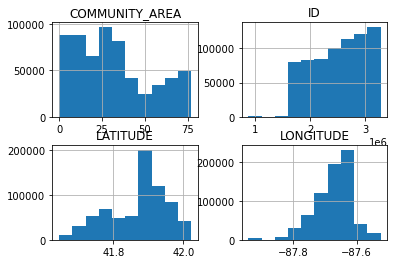

In [17]:
chicago_permits_df_sub.hist()

## Plotting a time series

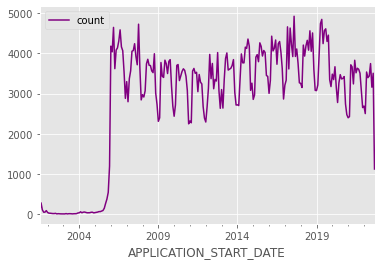

In [18]:
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
plt.style.use("ggplot")

data_df.plot(color="purple")

Notice how the number of applications in 2005 and before looks suspiciously low. My intuition is that this is a data problem. Let's remove all data from before 2006, since bad data will impact the accuracy of our model. Let's also remove data from before October of this year, since October is incomplete.

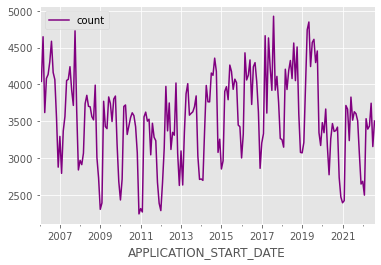

In [22]:
def is_between_2006_and_now(date):
    return date > datetime.datetime(2006, 1, 1) and date < datetime.datetime(2022, 9, 1)
#Please update the date range

data_df = data_df[data_df.index.to_series().apply(is_between_2006_and_now)]
data_df.plot(color="purple")

This plot makes two things pretty clear. First, there are some clear trends in the time series -- for example, an increase between 2011 and 2017, followed by a levelling off of permit applications. Second, there is a cyclic nature to the time series, which is indicative of there being seasonal variation in permit applications (which isn't surprising).

### Q3

Using your own dataset, create two different visualizations to analyze the data, using Python and any plotting library of your choice (e.g., Matplotlib, Seaborn, Plotly). For each dataset, spend some time observing the visualizations, and identify any significant patterns or trends you found. Describe the insights or trends revealed, and discuss how these findings can help address the research question you identified.

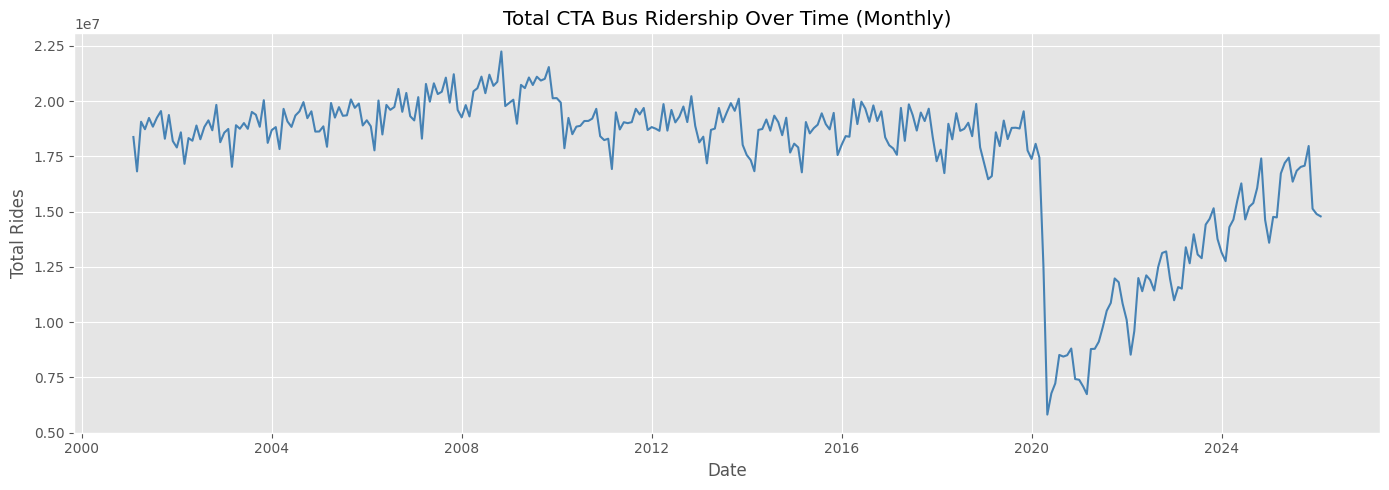

In [23]:
## TODO : Q3

import matplotlib.pyplot as plt
plt.style.use("ggplot")

# Visualization 1: Total CTA bus ridership over time (monthly)
monthly_ridership = chicago_bus_clean.copy()
monthly_ridership = monthly_ridership.set_index('date').resample('M')['rides'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_ridership['date'], monthly_ridership['rides'], color='steelblue')
plt.title('Total CTA Bus Ridership Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Total Rides')
plt.tight_layout()
plt.show()

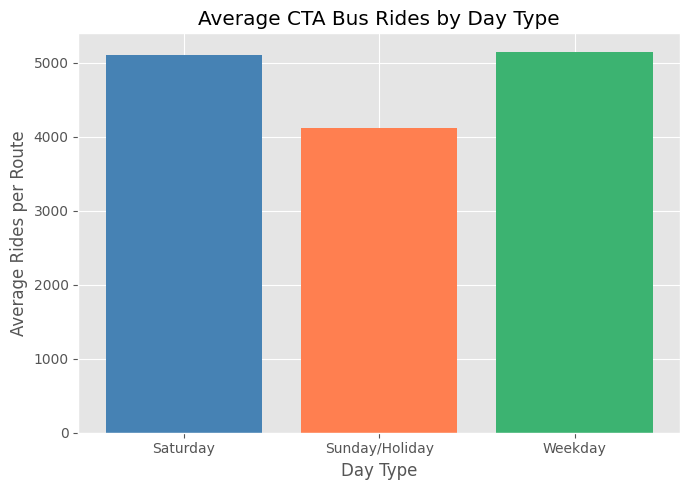

In [24]:
# Visualization 2: Average ridership by day type (Weekday vs Saturday vs Sunday)
daytype_avg = chicago_bus_clean.groupby('daytype')['rides'].mean().reset_index()
daytype_avg['daytype'] = daytype_avg['daytype'].map({'W': 'Weekday', 'A': 'Saturday', 'U': 'Sunday/Holiday'})

plt.figure(figsize=(7, 5))
plt.bar(daytype_avg['daytype'], daytype_avg['rides'], color=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Average CTA Bus Rides by Day Type')
plt.xlabel('Day Type')
plt.ylabel('Average Rides per Route')
plt.tight_layout()
plt.show()